# STAT 451: Heart Prediction Project

In [6]:
# import statements
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load dataframe
df = pd.read_csv('heart.csv')

def resumetable(df):
    print(f"data shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns=['data type'])
    summary = summary.reset_index()
    summary = summary.rename(columns = {"index": "feature"})
    summary["Num_Null"] = df.isnull().sum().values
    summary["Num_Unique"] = df.nunique().values
    summary["First_Value"] = df.loc[0].values
    summary["Second_Value"] = df.loc[1].values
    summary["Third_Value"] = df.loc[2].values

    return summary

resumetable(df)

data shape: (918, 12)


,feature,data type,Num_Null,Num_Unique,First_Value,Second_Value,Third_Value
0,Age,int64,0,50,40,49,37
1,Sex,object,0,2,M,F,M
2,ChestPainType,object,0,4,ATA,NAP,ATA
3,RestingBP,int64,0,67,140,160,130
4,Cholesterol,int64,0,222,289,180,283
5,FastingBS,int64,0,2,0,0,0
6,RestingECG,object,0,3,Normal,Normal,ST
7,MaxHR,int64,0,119,172,156,98
8,ExerciseAngina,object,0,2,N,N,N
9,Oldpeak,float64,0,53,0.0,1.0,0.0


### Data Preprocessing

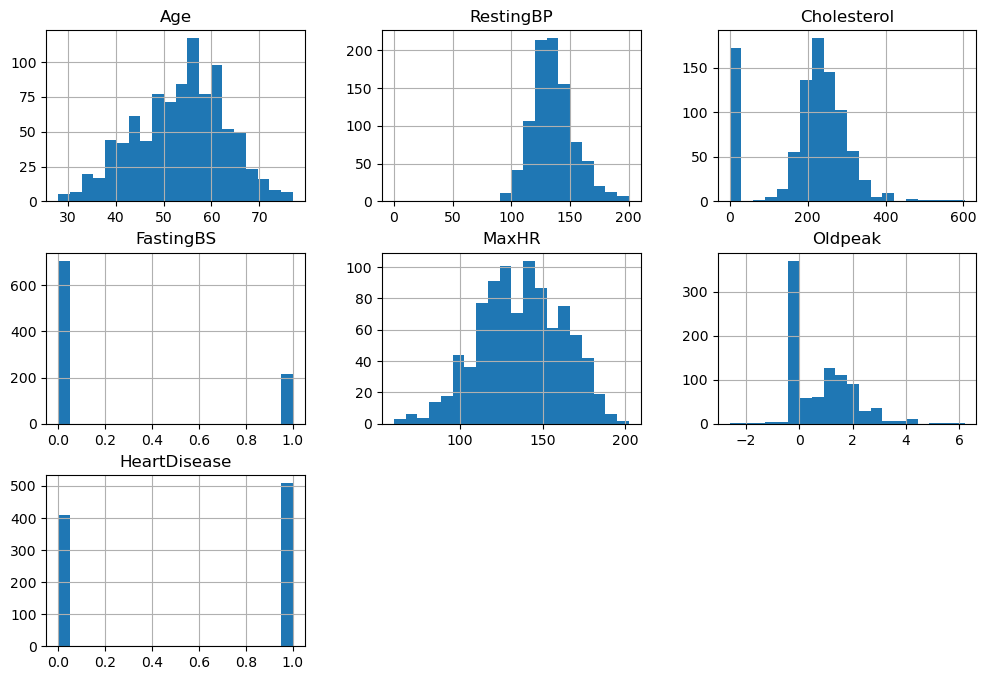

KeyError: "None of [Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')] are in the [columns]"

In [18]:
# Clean data by handling potential outliers
df.describe()

# Potential outlier: RestingBP with value 0
# Should I get rid of the row or use data imputation?

# Oldpeak = ST during rest - ST during excercise
# Should we only consider Oldpeak >= 0? Most datasets consider positive ones because exercise typically decrease depression
df['Oldpeak'].value_counts().sort_index() # negative values are rare

# Perform exploratory data analysis to understand variable distributions
df.hist(bins=20, figsize=(12, 8))
plt.show()

# Check for class imbalance
df['HeartDisease'].value_counts(normalize=True)

# Encode categorical variables + Scale numerical features
# categorical: Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope
df = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

### Feature Selection & Engineering

In [17]:
# ** pick one feature engineering (the most reasonable one), interaction term don't dominate
# Apply correlation analysis to identify relationships between features
# Use feature importance techniques to identify most predictive variables
# Create interaction terms between important features
# Conduct feature selection methods (SelectKBest)

### Model Development

In [ ]:
# Split data into training, validation, and test sets

# Implement multiple classification algorithms:
# Logistic regression
# Random forest (classifier)
# SVC
# Ensemble model (voting)

# Conduct hyperparameter tuning using GridsearchCV + RandomSearchCV

# Threshold optimization for each model

### Model Evaluation

In [ ]:
# Compare models using evaluation metrics ** think about which is the optimal
# Accuracy
# Precision
# Recall
# F1-Score
# ROC Curve
# AUC